# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals
---
* **Author**: Carmen-Theodora Craciun
* **The purpose of this Notebook**: This notebook handles ...
* **Datasets**: [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) and [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
    * Sleep Cassette (SC) - the study on healthy people;
    * Sleep Telemetry (ST) - sleep study in people with difficulty falling asleep. This study was designed to look at the effects of temazepam, a drug with hypnotic effects;
    * UCDDB - patients diagnosed with apnea, who do not suffer from cardiological diseases or autonomic dysfunctions and are not taking medication at the time of registration.
* **Input**:
  * class_distribution.csv
  * results.zip - a compressed archive containing the layered and prepared dataset for training (train, test, val)
    * each file in these folders represents a *processed sleep window* (epoch)
* **Output:**
  * `model_bilstm_baseline.pt`
  * `model_crnn.pt`
  * `model_resnet.pt`

# Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [4]:
import joblib
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

In [3]:
test_path_csv = 'process_dataset/extracted_features/test_features.csv'
test_path_raw = 'process_dataset/test'
class_distribution_path = 'process_dataset/class_distribution_train.csv'

In [6]:
import utils

In [7]:
results = pd.read_csv("./model_results.csv")

results['test_acc'] = None
results['test_kappa'] = None
results['ev_time'] = None
results['cf_matrix_path']=None

display(results.head(3))

,name,type,acc_mean,acc_std,kappa_mean,kappa_std,acc_best,kappa_best,fold_accs,fold_kappas,path,test_acc,test_kappa,roc_fpr,roc_tpr,roc_auc,ev_time,cf_matrix_path
0,LGBM,Tree-Based,0.771113,0.011058,0.688753,0.015881,0.785777,0.711319,"[0.7822102234378885, 0.7665833392014647, 0.756...","[0.7028607198228597, 0.6815896297628314, 0.668...",models/best_LGBM_calibrated.pkl,None,None,NaN,NaN,NaN,None,None
1,XGB,Tree-Based,0.770371,0.010155,0.688016,0.014584,0.783613,0.708600,"[0.7801854285815779, 0.7679388775438349, 0.756...","[0.7002627188458095, 0.6838012033399608, 0.668...",./models/best_XGB_calibrated.pkl,None,None,NaN,NaN,NaN,None,None
2,RF,Tree-Based,0.743268,0.011200,0.650749,0.016184,0.760179,0.676338,"[0.7523533799865013, 0.7389444405323569, 0.730...","[0.6624766935630217, 0.6433002138925756, 0.633...",./models/best_RF_calibrated.pkl,None,None,NaN,NaN,NaN,None,None


In [8]:
# from sklearn.preprocessing import label_binarize
# from sklearn.metrics import roc_curve, auc
# def compute_roc_df(y_true, y_proba):
#     # 1. Binarizezi etichetele
#     y_bin = label_binarize(y_true, classes=[0,1,2,3,4])
    
#     # 2. Calculezi ROC pentru fiecare clasă
#     fpr = {}
#     tpr = {}
#     roc_auc = {}
    
#     for i in range(5):
#         fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
#         roc_auc[i] = auc(fpr[i], tpr[i])
#     return fpr, tpr, roc_auc

# Dataset

In [8]:
df_test = pd.read_csv(test_path_csv)
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']
feature_cols = [c for c in df_test.columns if c not in cols_to_drop]
X_test = df_test[feature_cols]
y_test = df_test['Label']
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test.fillna(0))
X_test_seq, y_test_seq, _ = utils.build_sequences_per_subject(df_test, feature_cols, seq_len=30, step=5)

# Models test

## LightGBM

Confusion matrix saved at: results/confusion_matrix_LGBM.png
Accuracy: 0.7811
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.52      0.27      0.36      5307
          N2       0.79      0.90      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.80      0.78      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



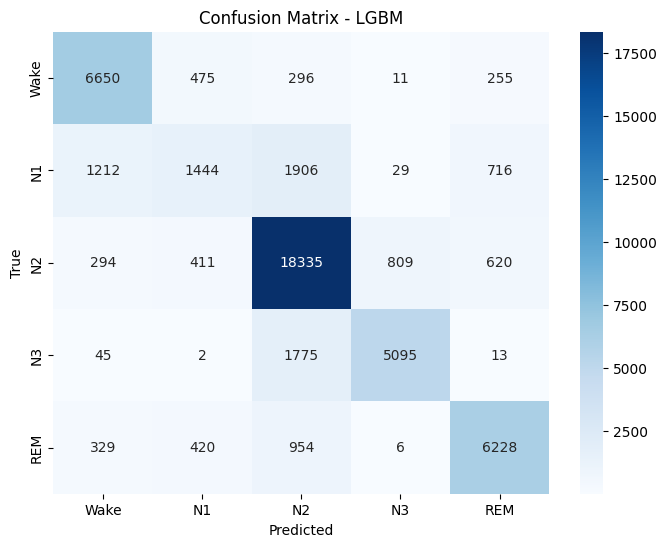

Cohen's Kappa: 0.6950


In [9]:
mask = (results['name'] == 'LGBM')
lgbm_model = joblib.load(results.loc[mask,'path'].values[0])
# Predict calibrated probabilities
start_time = time.time()
y_proba_lgbm = lgbm_model.predict_proba(X_test)
# Predict final class
y_pred_test_lgm = lgbm_model.predict(X_test)
end_time = time.time()

# Save metrics
results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test,
    y_pred_test_lgm,
    save_folder='results',
    model_name='LGBM'
)

## XGBoost

Confusion matrix saved at: results/confusion_matrix_XGB.png
Accuracy: 0.7804
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.86      0.82      7687
          N1       0.52      0.28      0.36      5307
          N2       0.79      0.89      0.84     20469
          N3       0.85      0.73      0.79      6930
         REM       0.79      0.79      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



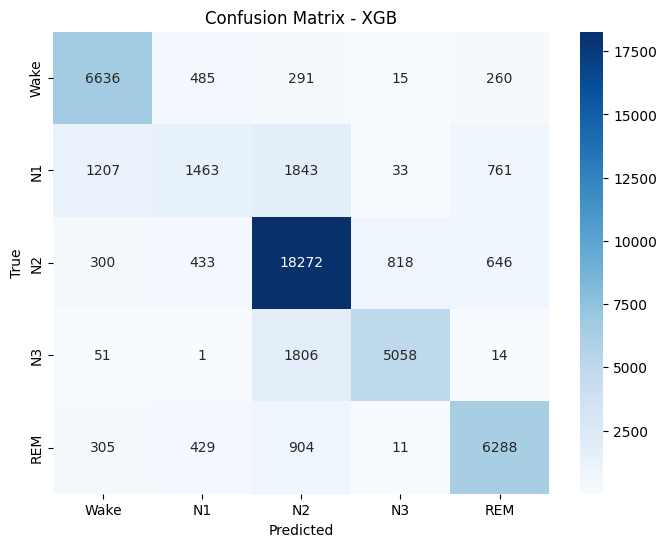

Cohen's Kappa: 0.6943


In [10]:
mask = (results['name'] == 'XGB')
xgb_model = joblib.load(results.loc[mask,'path'].values[0])
start_time = time.time()
# Predict calibrated probabilities
y_proba_xgb = xgb_model.predict_proba(X_test)
# Predict final class
y_pred_test_xgb = xgb_model.predict(X_test)
end_time = time.time()

results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test,
    y_pred_test_xgb,
    save_folder='results',
    model_name='XGB'
)

## Random Forest

Confusion matrix saved at: results/confusion_matrix_RF.png
Accuracy: 0.7523
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.72      0.82      0.77      7687
          N1       0.49      0.24      0.32      5307
          N2       0.78      0.87      0.82     20469
          N3       0.85      0.70      0.77      6930
         REM       0.74      0.79      0.76      7937

    accuracy                           0.75     48330
   macro avg       0.71      0.68      0.69     48330
weighted avg       0.74      0.75      0.74     48330



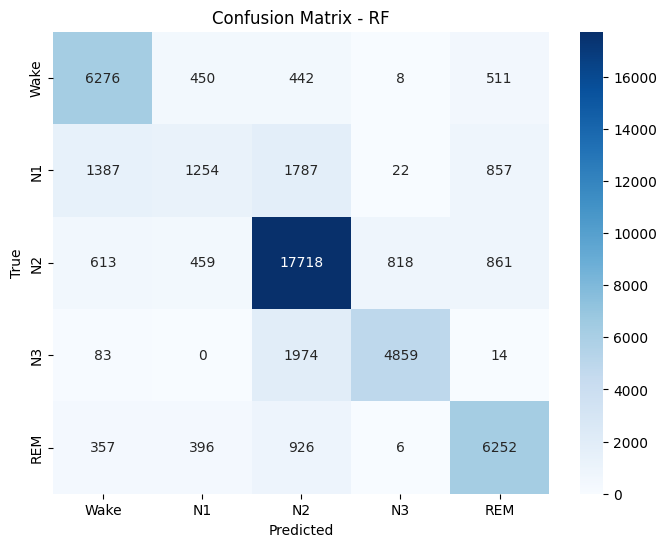

Cohen's Kappa: 0.6557


In [11]:
mask = (results['name'] == 'RF')
rf_model = joblib.load(results.loc[mask,'path'].values[0])
start_time = time.time()
# Predict calibrated probabilities
y_proba_rf = rf_model.predict_proba(X_test)
# Predict final class
y_pred_test_rf = rf_model.predict(X_test)
end_time = time.time()

results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test,
    y_pred_test_rf,
    save_folder='results',
    model_name='RF'
)

## LDA

Confusion matrix saved at: results/confusion_matrix_LDA.png
Accuracy: 0.7352
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.76      0.72      0.74      7687
          N1       0.41      0.31      0.35      5307
          N2       0.77      0.85      0.81     20469
          N3       0.79      0.69      0.74      6930
         REM       0.72      0.79      0.75      7937

    accuracy                           0.74     48330
   macro avg       0.69      0.67      0.68     48330
weighted avg       0.73      0.74      0.73     48330



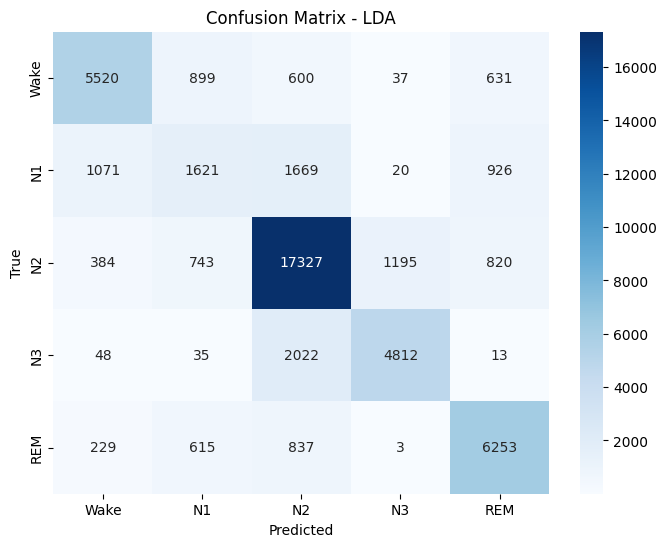

Cohen's Kappa: 0.6338


In [12]:
mask = (results['name'] == 'LDA')
lda_model = joblib.load(results.loc[mask,'path'].values[0])
start_time = time.time()
# Predict calibrated probabilities
y_proba_lda = lda_model.predict_proba(X_test_scaled)
# Predict final class
y_pred_test_lda = lda_model.predict(X_test_scaled)
end_time = time.time()

results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test,
    y_pred_test_lda,
    save_folder='results',
    model_name='LDA'
)

## Logistic Regression

Confusion matrix saved at: results/confusion_matrix_LR.png
Accuracy: 0.7213
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.73      0.74      7687
          N1       0.35      0.44      0.39      5307
          N2       0.87      0.72      0.79     20469
          N3       0.72      0.84      0.77      6930
         REM       0.69      0.81      0.75      7937

    accuracy                           0.72     48330
   macro avg       0.68      0.71      0.69     48330
weighted avg       0.74      0.72      0.73     48330



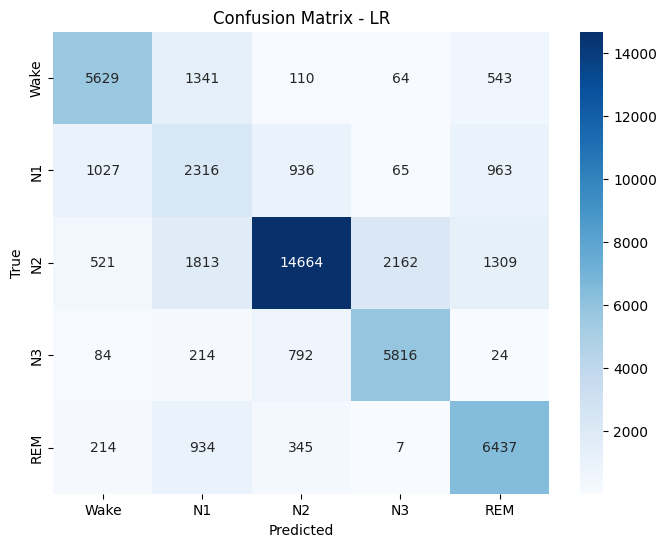

Cohen's Kappa: 0.6319


In [13]:
mask = (results['name'] == 'LR')
lr_model = joblib.load(results.loc[mask,'path'].values[0])
start_time = time.time()
# Predict calibrated probabilities
y_proba_lr = lr_model.predict_proba(X_test_scaled)
# Predict final class
y_pred_test_lr = lr_model.predict(X_test_scaled)
# utils.evaluate_model(y_test, y_pred_test_lr)
end_time = time.time()
results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test,
    y_pred_test_lr,
    save_folder='results',
    model_name='LR'
)

## MLP

E0000 00:00:1782321844.098793 3310433 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Confusion matrix saved at: results/confusion_matrix_MLP.png
Accuracy: 0.7842
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.77      0.88      0.82      7687
          N1       0.51      0.32      0.39      5307
          N2       0.81      0.88      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.79      0.80      0.80      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.72      0.73     48330
weighted avg       0.77      0.78      0.77     48330



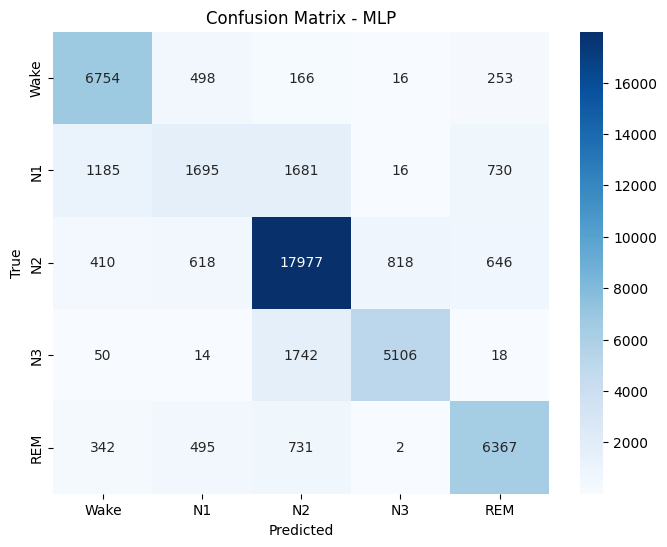

Cohen's Kappa: 0.7016


In [14]:
mask = (results['name'] == 'MLP')
mlp_model = load_model(results.loc[mask,'path'].values[0])
y_proba_mlp = mlp_model.predict(X_test)
y_pred_test_mlp = y_proba_mlp.argmax(axis=1)
results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test,
    y_pred_test_mlp,
    save_folder='results',
    model_name='MLP'
)

## LSTM

292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Confusion matrix saved at: results/confusion_matrix_LSTM.png
Accuracy: 0.7889
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.89      0.84      1395
          N1       0.53      0.26      0.35       977
          N2       0.80      0.86      0.83      3996
          N3       0.80      0.76      0.78      1387
         REM       0.82      0.86      0.84      1585

    accuracy                           0.79      9340
   macro avg       0.75      0.73      0.73      9340
weighted avg       0.77      0.79      0.78      9340



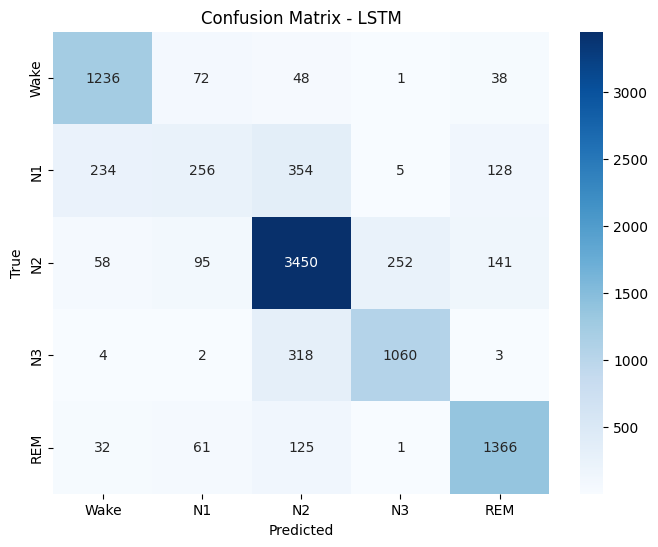

Cohen's Kappa: 0.7073


In [15]:
mask = (results['name'] == 'LSTM')
lstm_model = load_model(
    results.loc[mask,'path'].values[0],
    custom_objects={
        "se_feature_attention": utils.se_feature_attention,
        "focal_loss": utils.categorical_focal_loss
    },
    compile=False
)
start_time = time.time()
y_proba_lstm = lstm_model.predict(X_test_seq)
y_pred_test_lstm = y_proba_lstm.argmax(axis=1)
end_time = time.time()

results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test_seq, y_pred_test_lstm,
    save_folder='results',
    model_name='LSTM'
)

## ResNet

292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Confusion matrix saved at: results/confusion_matrix_ResNet.png
Accuracy: 0.7819
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.83      0.81      1395
          N1       0.46      0.34      0.39       977
          N2       0.80      0.87      0.83      3996
          N3       0.82      0.77      0.79      1387
         REM       0.84      0.81      0.82      1585

    accuracy                           0.78      9340
   macro avg       0.74      0.72      0.73      9340
weighted avg       0.77      0.78      0.78      9340



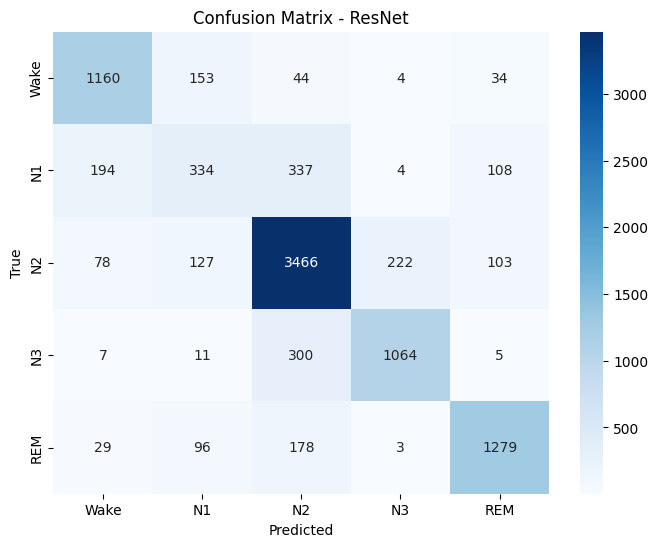

Cohen's Kappa: 0.6979


In [16]:
mask = (results['name'] == 'ResNet')
resnet_model = load_model(
    results.loc[mask,'path'].values[0],
    compile=False
)
start_time = time.time()
y_proba_resnet = resnet_model.predict(X_test_seq)
y_pred_test_resnet = y_proba_resnet.argmax(axis=1)
end_time = time.time()
results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_test_seq, y_pred_test_resnet,
    save_folder='results',
    model_name='ResNet'
)

## 1D-CNN

57/57 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step
Confusion matrix saved at: results/confusion_matrix_CNN.png
Accuracy: 0.7704
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.73      0.94      0.82      7621
          N1       0.51      0.19      0.27      5260
          N2       0.80      0.87      0.83     20468
          N3       0.79      0.77      0.78      6930
         REM       0.77      0.75      0.76      7937

    accuracy                           0.77     48216
   macro avg       0.72      0.70      0.69     48216
weighted avg       0.75      0.77      0.75     48216



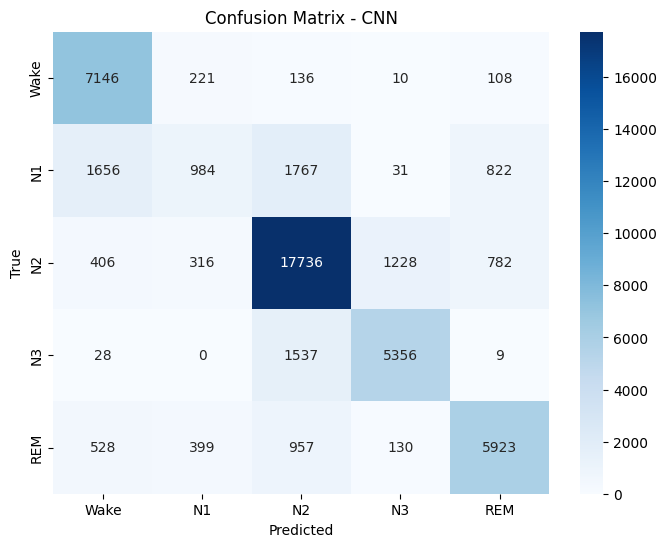

Cohen's Kappa: 0.6822


In [17]:
test_gen = utils.SleepDataGenerator(
    test_path_raw,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

mask = (results['name'] == 'CNN')
cnn_model = load_model(results.loc[mask,'path'].values[0], compile=False)
start_time = time.time()
# Predict probabilities
y_proba_cnn = cnn_model.predict(test_gen)

# Predict final class
y_pred_cnn = y_proba_cnn.argmax(axis=1)
end_time = time.time()


# Extract true labels from generator
y_true_cnn = []
for i in range(len(test_gen)):
    _, y_batch = test_gen[i]
    y_true_cnn.extend(np.argmax(y_batch, axis=1))
y_true_cnn = np.array(y_true_cnn)

# Save metrics
results.loc[mask,'ev_time'] = end_time - start_time
results.loc[mask,'test_acc'], \
results.loc[mask,'test_kappa'], \
results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
    y_true_cnn,
    y_pred_cnn,
    save_folder='results',
    model_name='CNN'
)

# Ensemble

In [38]:
import numpy as np

def ensemble_weight_search(y_true, y_proba_A, y_proba_B):
    best_w = None
    best_kappa = -999
    best_acc = -999

    for w in np.linspace(0, 1, 21):  # 0.00, 0.05, ..., 1.00
        y_proba_ens = w * y_proba_A + (1 - w) * y_proba_B
        y_pred_ens = y_proba_ens.argmax(axis=1)

        acc, kappa = evaluate_model(
            y_true,
            y_pred_ens,
            disable_view=False
        )
        
        if kappa > best_kappa:
            best_kappa = kappa
            best_acc = acc
            best_w = w

    return best_w, best_acc, best_kappa

## LGBM + MLP

In [39]:
best_w, best_acc, best_kappa = ensemble_weight_search(
    y_test,
    y_proba_lgbm,
    y_proba_mlp
)

print("Best weight:", best_w)
print("Best acc:", best_acc)
print("Best kappa:", best_kappa)

Best weight: 0.35000000000000003
Best acc: 0.7904614111318022
Best kappa: 0.7092007290632181


Confusion matrix saved at: results/confusion_matrix_LGBM_MLP.png
Accuracy: 0.7905
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.89      0.83      7687
          N1       0.55      0.30      0.39      5307
          N2       0.80      0.89      0.84     20469
          N3       0.87      0.74      0.80      6930
         REM       0.80      0.81      0.80      7937

    accuracy                           0.79     48330
   macro avg       0.76      0.73      0.73     48330
weighted avg       0.78      0.79      0.78     48330



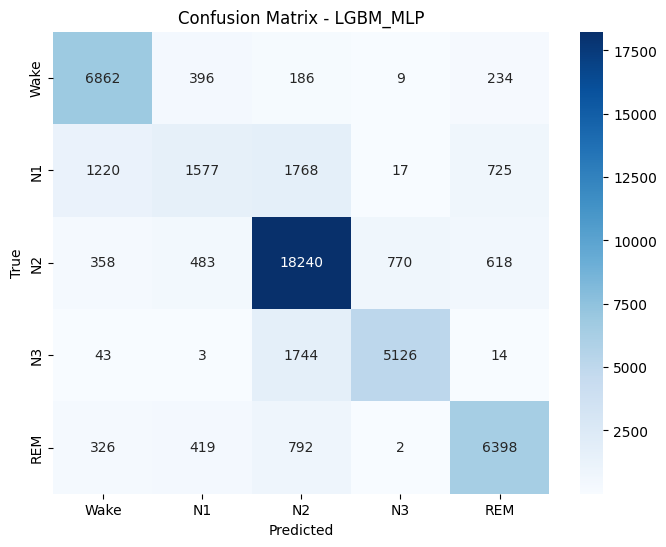

Cohen's Kappa: 0.7092


In [40]:
start_time = time.time()
y_proba_ens = best_w * y_proba_lgbm + (1 - best_w) * y_proba_mlp
y_pred_ens = y_proba_ens.argmax(axis=1)
end_time = time.time()

acc_ens, kappa_ens, path = utils.evaluate_model(
    y_test, y_pred_ens,
    save_folder='results',
    model_name='LGBM_MLP'
)

results.loc[len(results)] = {
    "name": "LGBM_MLP",
    "type": "Ensemble",
    "test_acc": acc_ens,
    "test_kappa": kappa_ens,
    "ev_time": end_time - start_time,
    "cf_matrix_path": path,
    "path": None
}

## LSTM + ResNet

In [41]:
best_w, best_acc, best_kappa = ensemble_weight_search(
    y_test_seq,
    y_proba_lstm,
    y_proba_resnet
)

print("Best weight:", best_w)
print("Best acc:", best_acc)
print("Best kappa:", best_kappa)

Best weight: 0.65
Best acc: 0.797644539614561
Best kappa: 0.7193767444068297


Confusion matrix saved at: results/confusion_matrix_LSTM_ResNet.png
Accuracy: 0.7976
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.81      0.87      0.84      1395
          N1       0.54      0.33      0.41       977
          N2       0.81      0.87      0.84      3996
          N3       0.82      0.78      0.80      1387
         REM       0.83      0.85      0.84      1585

    accuracy                           0.80      9340
   macro avg       0.76      0.74      0.74      9340
weighted avg       0.79      0.80      0.79      9340



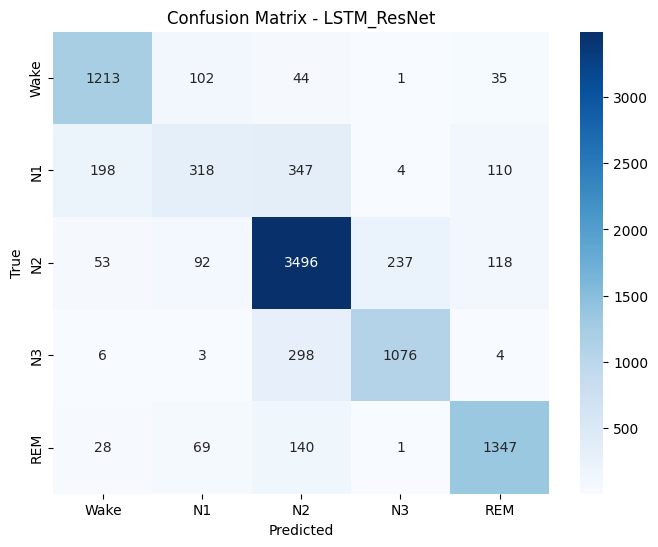

Cohen's Kappa: 0.7194


In [42]:
start_time = time.time()
y_proba_ens = best_w * y_proba_lstm + (1 - best_w) * y_proba_resnet
y_pred_ens_seq = y_proba_ens.argmax(axis=1)
end_time = time.time()

acc_ens, kappa_ens, path = utils.evaluate_model(
    y_test_seq, y_pred_ens_seq,
    save_folder='results',
    model_name='LSTM_ResNet'
)

results.loc[len(results)] = {
    "name": "LSTM_ResNet",
    "type": "Ensemble",
    "test_acc": acc_ens,
    "test_kappa": kappa_ens,
    "ev_time": end_time - start_time,
    "cf_matrix_path": path,
    "path": None
}

In [33]:
import utils
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from scipy.signal import medfilt, resample
from tensorflow.keras import layers

def load_any_keras_model(path):
    custom_objects = {
        "loss": utils.categorical_focal_loss(),   # pentru modelele care au "loss" în config
        "categorical_focal_loss": utils.categorical_focal_loss(),
        "se_feature_attention": utils.se_feature_attention,
        "Attention": utils.Attention,
    }

    return tf.keras.models.load_model(
        path,
        custom_objects=custom_objects,
        compile=False
    )

class Attention(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, inputs):
        score = self.V(tf.nn.tanh(self.W(inputs)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * inputs, axis=1)
        return context

def extract_from_generator(gen):
    X_list, y_list = [], []

    for i in range(len(gen)):
        Xb, yb = gen[i]
        X_list.append(Xb)
        y_list.append(np.argmax(yb, axis=1))

    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

Running: LGBM  | name_key: lgbm  | len(y): 48330
Running: XGB  | name_key: xgb  | len(y): 48330
Running: RF  | name_key: rf  | len(y): 48330
Running: LDA  | name_key: lda  | len(y): 48330
Running: LR  | name_key: lr  | len(y): 48330
Running: MLP  | name_key: mlp  | len(y): 48330
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Running: LSTM  | name_key: lstm  | len(y): 9340
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
Running: ResNet  | name_key: resnet  | len(y): 9340
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Running: CNN  | name_key: cnn  | len(y): 48216
1507/1507 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step
Running: LGBM_MLP  | name_key: lgbm_mlp  | len(y): 48330
Running: LSTM_ResNet  | name_key: lstm_resnet  | len(y): 9340


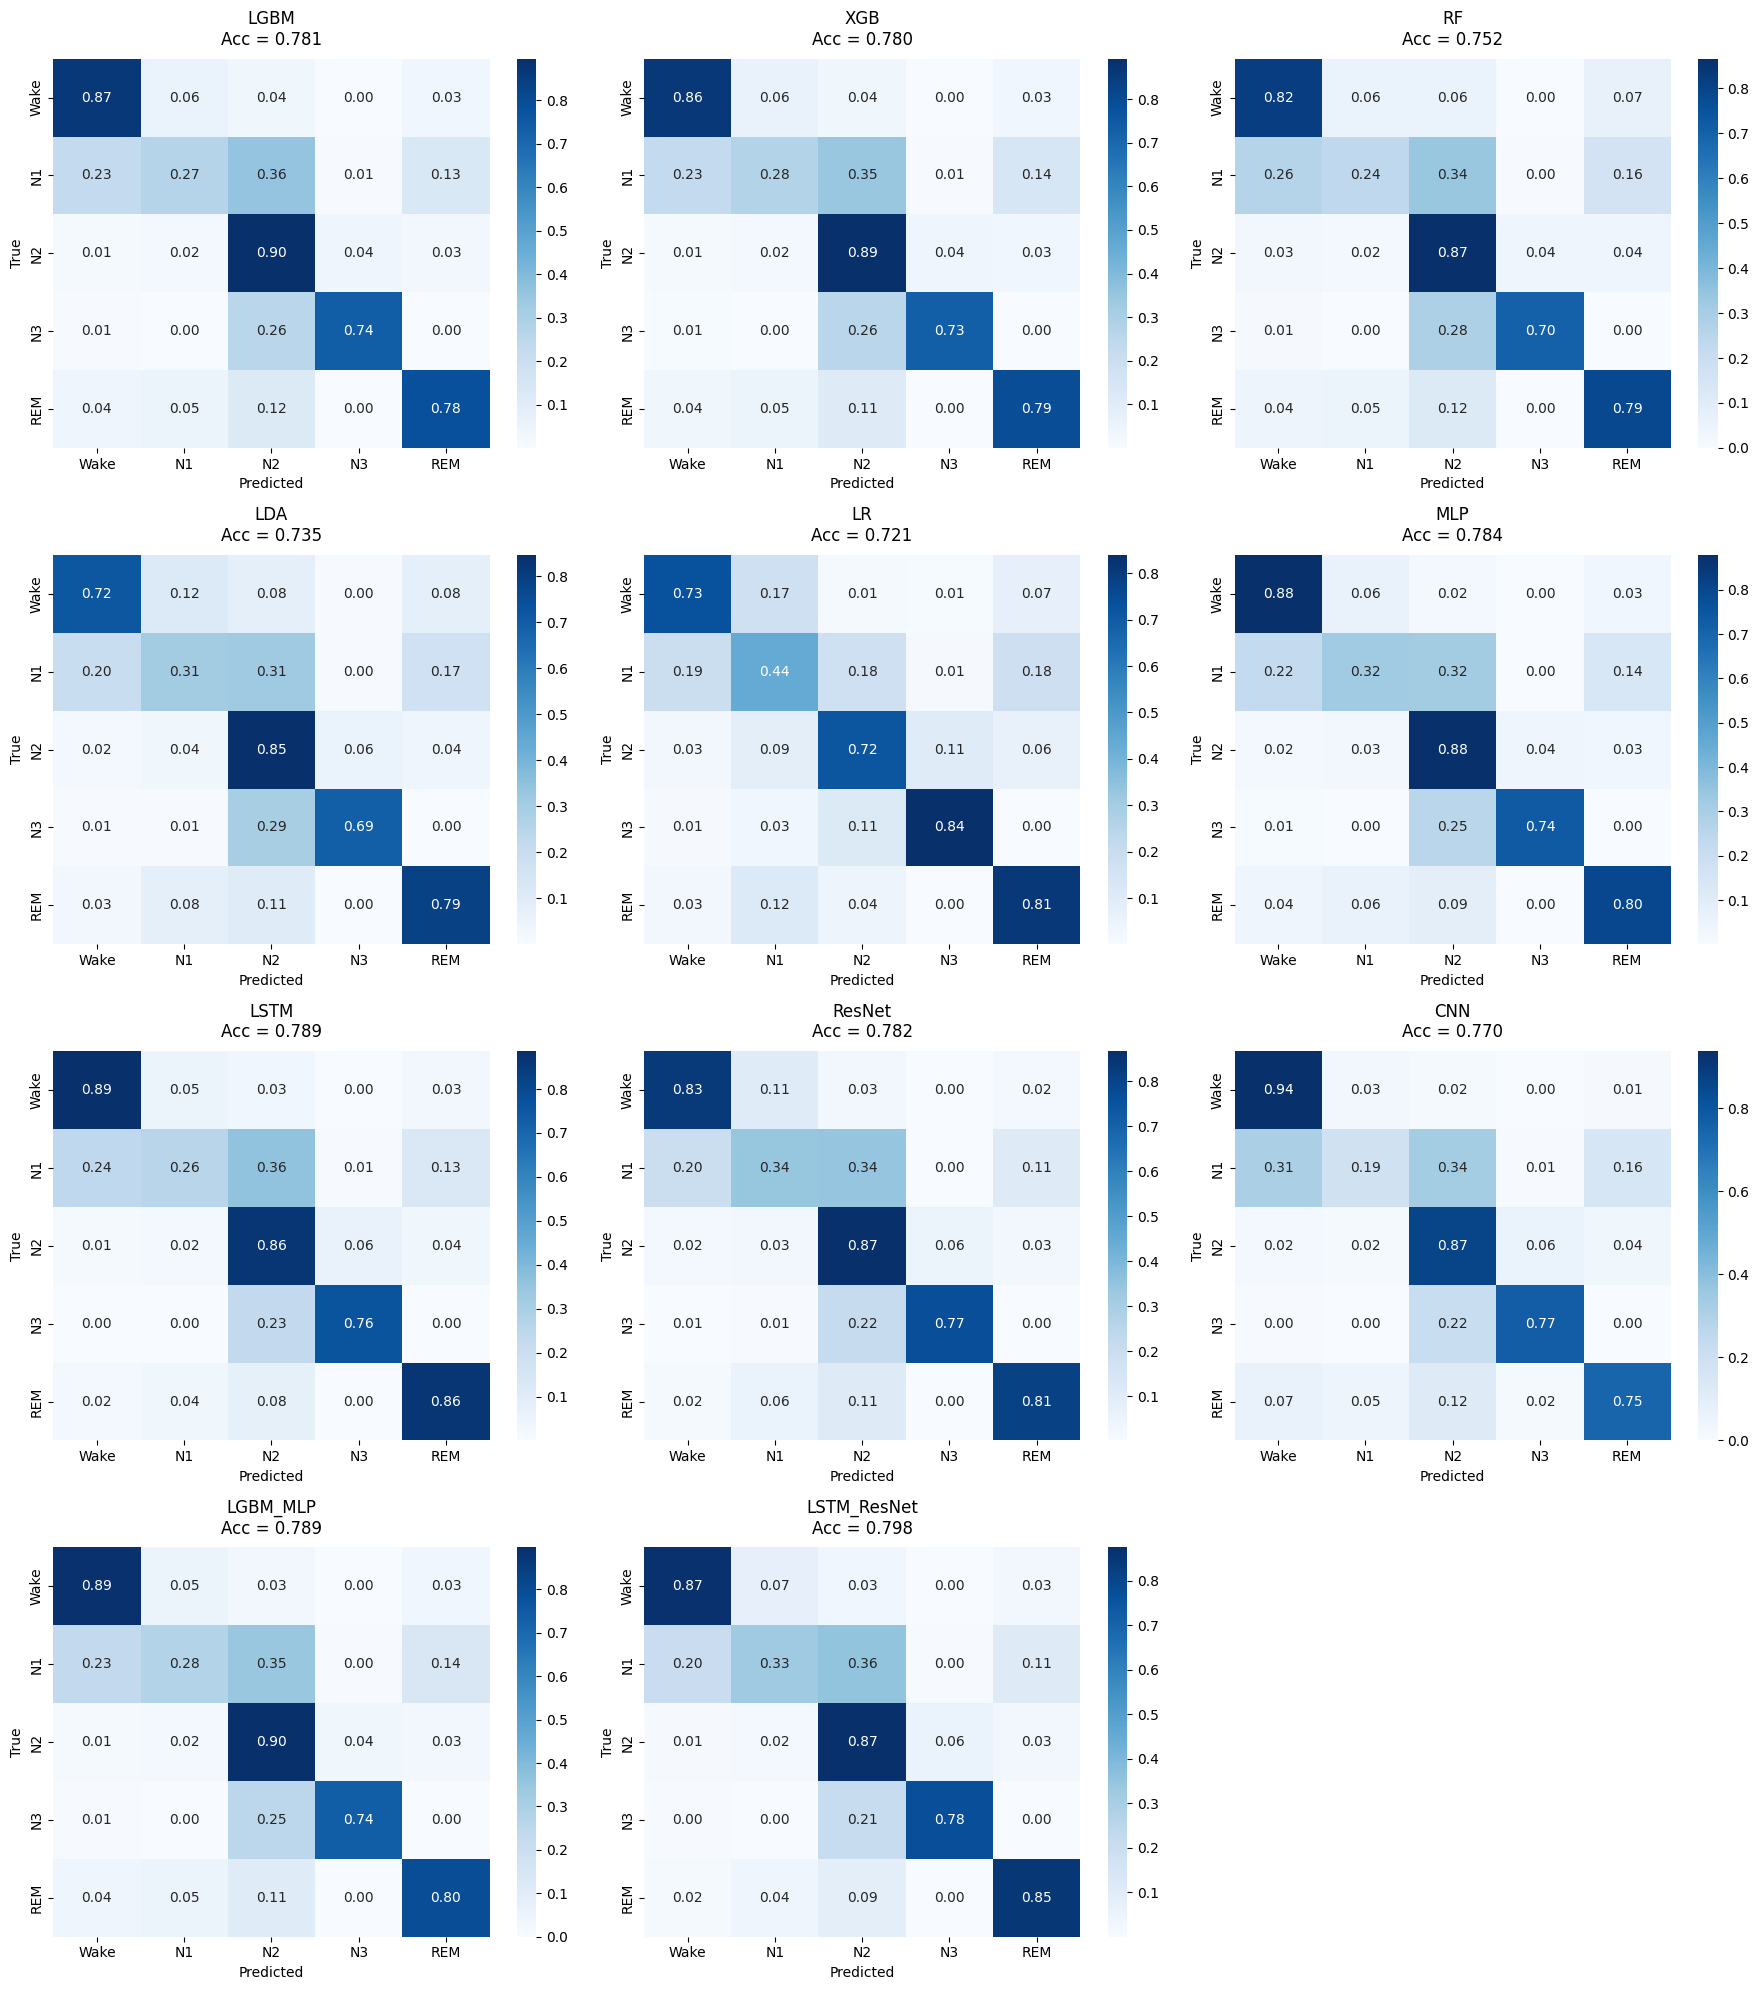

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import joblib
import tensorflow as tf
import utils

class_names = ["Wake", "N1", "N2", "N3", "REM"]

# -----------------------------
# 1. Loader universal pentru .keras
# -----------------------------
def load_any_keras_model(path):
    custom_objects = {
        "loss": utils.categorical_focal_loss(),
        "categorical_focal_loss": utils.categorical_focal_loss(),
        "se_feature_attention": utils.se_feature_attention,
        "Attention": Attention,
    }
    return tf.keras.models.load_model(path, custom_objects=custom_objects, compile=False)

def load_model(path):
    if not isinstance(path, str):
        return None
    if path.endswith(".pkl"):
        return joblib.load(path)
    if path.endswith(".keras"):
        return load_any_keras_model(path)
    return None

def get_predictions(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    return model.predict(X)

# -----------------------------
# 2. Extractor pentru CNN generator
# -----------------------------
def extract_from_generator(gen):
    X_list, y_list = [], []
    for i in range(len(gen)):
        Xb, yb = gen[i]
        X_list.append(Xb)
        y_list.append(np.argmax(yb, axis=1))
    return np.concatenate(X_list), np.concatenate(y_list)

# -----------------------------
# 3. Alegerea datasetului corect
# -----------------------------
def select_dataset(name, path):
    name_low = name.lower()

    # CNN
    if "cnn" in name_low:
        return extract_from_generator(test_gen)

    # Modele SEQ (LSTM, ResNet, SeqSleepNet)
    if any(key in name_low for key in ["lstm", "resnet", "seqsleep", "seq"]):
        return X_test_seq, y_test_seq

    # Modele clasice + MLP (tabulare)
    return X_test, y_test

# -----------------------------
# 4. Ensemble mapping (corect!)
# -----------------------------
ensemble_preds = {
    "lgbm_mlp": y_pred_ens,          # tabular
    "lstm_resnet": y_pred_ens_seq,   # seq
}

# -----------------------------
# 5. Plotarea tuturor matricilor
# -----------------------------
num_models = len(results)
cols = 3
rows = int(np.ceil(num_models / cols))

plt.figure(figsize=(cols * 6, rows * 5))

for idx, row in results.iterrows():
    name = row["name"]
    path = row["path"]

    # dataset corect
    X, y = select_dataset(name, path)

    # cheia standardizată
    name_key = name.lower().replace(" ", "").replace("-", "_")
    print("Running:", name, " | name_key:", name_key, " | len(y):", len(y))
    # Ensemble?
    if name_key in ensemble_preds:
        y_pred = ensemble_preds[name_key]

    else:
        model = load_model(path)
        y_proba = get_predictions(model, X)
        y_pred = np.argmax(y_proba, axis=1)

    # Matrice confuzie
    cm = confusion_matrix(y, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    plt.subplot(rows, cols, idx + 1)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)

    plt.title(f"{name}\nAcc = {row['test_acc']:.3f}", fontsize=12, pad=10)
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()

plt.show()

In [46]:
results.to_csv("./model_results.csv", index=False)

In [49]:
import shutil

shutil.make_archive("results", "zip", "results")

'/home/ubuntu/results.zip'